# ImageNet-1K HWIL — Softmax IP (K=1000 padded to 1024)

**K = 1000** (actual classes) to **Padded to 1024** (128 beats, 8 scanner blocks)

### Architecture: 2-Pass Streaming
- **Pass 1**: Block-scan max + sum_exp (pre-scan eliminates per-beat rescaling)
- **Pass 2**: Normalize (exp2 × recip)  AXI-S output
- **Bus**: 128-bit AXI-Stream, 8 elements/beat, 333 MHz, 0 DSP, 2 BRAM

### Evaluation Mode
- **Adaptive scaling** to prevent Q4.12 saturation

In [1]:
from IPython.display import display, HTML

display(HTML('''
<style>
    /* Increase output cell size */
    .jp-Cell-outputArea, 
    .output_wrapper, 
    .output_area,
    .jp-OutputArea {
        max-width: 100% !important;
        width: 100% !important;
    }
    
    /* Increase content size */
    .jp-OutputArea-child {
        max-width: 100% !important;
        width: 100% !important;
    }
    
    /* Increase notebook container size */
    .jp-Notebook, 
    .container {
        width: 95% !important;
        max-width: 95% !important;
    }
    
    /* Increase rendered HTML size */
    .jp-RenderedHTMLCommon {
        max-width: 100% !important;
    }
</style>
'''))

In [2]:
# =========================================================================
# Configuration and Hardware Setup
# =========================================================================
import numpy as np, time, csv, os, json
import torch, torch.nn as nn, torch.nn.functional as F
from pynq import Overlay, allocate, MMIO
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

# ============ CONFIG ============
BITSTREAM    = 'my_softmax15.bit'
IP_NAME      = 'softmax_dl2_v6_0'
DMA_NAME     = 'axi_dma_0'

NUM_CLASSES  = 1000
MIN_PAD      = 128            # BLOCK_SIZE(16) × LANES(8)
K_IP         = 1024           
IP_FCLK_HZ   = 333_000_000
AXIS_WIDTH   = 128
IN_FRAC      = 12; OUT_FRAC = 15

# Adaptive scaling
TARGET_MAX   = 7.0
Q412_MIN     = -8.0
Q412_MAX     = 32767.0 / (2**IN_FRAC)
PAD_Q412     = int(Q412_MIN * (2**IN_FRAC))  # -32768

# Data
LOGITS_NPZ   = 'imagenet_logits_10000.npz'
WEIGHTS_PATH = 'mobilenet_v2_imagenet.pth'
N_TEST       = 10000
LOG_CSV      = 'imagenet_v6_hwil.csv'
MISMATCH_DIR = 'mismatches_imagenet_v6'
os.makedirs(MISMATCH_DIR, exist_ok=True)

# Load ImageNet class names
try:
    with open('imagenet_classes.json') as f:
        CLASS_NAMES = json.load(f)
    print(f'Loaded {len(CLASS_NAMES)} class names from imagenet_classes.json')
except:
    CLASS_NAMES = [f'class_{i}' for i in range(1000)]
    print('WARNING: imagenet_classes.json not found, using generic names')

print(f'K={NUM_CLASSES} (pad{K_IP}), TARGET_MAX={TARGET_MAX}')

/usr/local/share/pynq-venv/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 
  warn(f"Failed to load image Python extension: {e}")


Loaded 1000 class names from imagenet_classes.json
K=1000 (pad1024), TARGET_MAX=7.0


In [3]:
# =========================================================================
# Hardware Setup and Softmax Runner
# =========================================================================
overlay = Overlay(BITSTREAM)
dma = getattr(overlay, DMA_NAME)
dma_send = dma.sendchannel
dma_recv = dma.recvchannel
mmio = MMIO(overlay.ip_dict[IP_NAME]['phys_addr'], 0x10000)

# === v6.0 Register Map ===
REG_CTRL       = 0x00
REG_STATUS     = 0x04
REG_ARGMAX_IDX = 0x08
REG_ARGMAX_VAL = 0x0C
REG_TOTAL_LO   = 0x10; REG_TOTAL_HI  = 0x14
REG_P1_LO      = 0x18; REG_P1_HI     = 0x1C
REG_P2_LO      = 0x20; REG_P2_HI     = 0x24
REG_STALL_LO   = 0x28; REG_STALL_HI  = 0x2C
REG_K_CONFIG   = 0x30
REG_COMPUTE_LO = 0x34; REG_COMPUTE_HI = 0x38

CTRL_START_P1=0x01; CTRL_START_P2=0x02
CTRL_CLEAR_PERF=0x04; CTRL_CLEAR_ERR=0x08
STATUS_P1_DONE=0x01; STATUS_ERROR=0x08

def rd64(lo, hi): return (mmio.read(hi) << 32) | mmio.read(lo)

N_BEATS   = K_IP // 8    # 128 beats
BUF_WORDS = N_BEATS * 4  # 512 uint32 words

try: in_buf.freebuffer(); out_buf.freebuffer()
except: pass
in_buf  = allocate(shape=(BUF_WORDS,), dtype=np.uint32)
out_buf = allocate(shape=(BUF_WORDS,), dtype=np.uint32)

# Write K_CONFIG
mmio.write(REG_K_CONFIG, K_IP)

def pack_128b(full_int16):
    u = full_int16.view(np.uint16).astype(np.uint32)
    r = np.empty(BUF_WORDS, dtype=np.uint32)
    for b in range(N_BEATS):
        s = b * 8
        r[b*4+0] = u[s]   | (u[s+1] << 16)
        r[b*4+1] = u[s+2] | (u[s+3] << 16)
        r[b*4+2] = u[s+4] | (u[s+5] << 16)
        r[b*4+3] = u[s+6] | (u[s+7] << 16)
    return r

def unpack_128b(u32):
    p = np.empty(K_IP, dtype=np.uint16)
    for b in range(N_BEATS):
        w = u32[b*4:b*4+4].astype(np.uint32); s = b * 8
        p[s]   = w[0] & 0xFFFF;       p[s+1] = (w[0] >> 16) & 0xFFFF
        p[s+2] = w[1] & 0xFFFF;       p[s+3] = (w[1] >> 16) & 0xFFFF
        p[s+4] = w[2] & 0xFFFF;       p[s+5] = (w[2] >> 16) & 0xFFFF
        p[s+6] = w[3] & 0xFFFF;       p[s+7] = (w[3] >> 16) & 0xFFFF
    return p[:NUM_CLASSES].astype(np.float64) / (2**OUT_FRAC)

def adaptive_scale(logits, target=TARGET_MAX):
    mx = np.max(np.abs(logits))
    return (target / mx) if mx > target else 1.0

def run_softmax_ip(logits):
    """Run full 2-Pass Softmax IP v6.0 with adaptive scaling."""
    logits_f64 = np.array(logits[:NUM_CLASSES], dtype=np.float64)
    scale = adaptive_scale(logits_f64)
    scaled = logits_f64 * scale
    clipped = np.clip(scaled, Q412_MIN, Q412_MAX)
    sat = int(np.sum(np.abs(scaled) > Q412_MAX))
    q_int16 = np.round(clipped * (2**IN_FRAC)).astype(np.int16)
    full = np.full(K_IP, PAD_Q412, dtype=np.int16)
    full[:NUM_CLASSES] = q_int16
    packed = pack_128b(full)
    np.copyto(in_buf, packed)
    mmio.write(REG_CTRL, CTRL_CLEAR_PERF)
    # === Pass 1: Block-scan max + sum_exp ===
    mmio.write(REG_CTRL, CTRL_START_P1)
    dma_send.transfer(in_buf)
    dma_send.wait()
    for _ in range(2_000_000):
        if mmio.read(REG_STATUS) & STATUS_P1_DONE:
            break
    # === Pass 2: Normalize  output (auto_p2_en=1) ===
    dma_recv.transfer(out_buf)
    mmio.write(REG_CTRL, CTRL_START_P2)
    dma_send.transfer(in_buf)  # Send same data again
    dma_send.wait()
    dma_recv.wait()
    # Read results
    probs = unpack_128b(np.array(out_buf))
    aidx = mmio.read(REG_ARGMAX_IDX)
    status = mmio.read(REG_STATUS)
    hw_err = bool(status & STATUS_ERROR)
    if hw_err:
        mmio.write(REG_CTRL, CTRL_CLEAR_ERR)
    pred = int(aidx) if aidx < NUM_CLASSES else int(np.argmax(probs))
    perf = {
        'total':   int(rd64(REG_TOTAL_LO, REG_TOTAL_HI)),
        'p1':      int(rd64(REG_P1_LO, REG_P1_HI)),
        'p2':      int(rd64(REG_P2_LO, REG_P2_HI)),
        'stall':   int(rd64(REG_STALL_LO, REG_STALL_HI)),
        'compute': int(rd64(REG_COMPUTE_LO, REG_COMPUTE_HI)),
        'sat': sat, 'scale': scale, 'hw_error': hw_err
    }
    return probs, pred, perf

# Sanity check
test = np.random.randn(NUM_CLASSES) * 20
p, pred, pf = run_softmax_ip(test)
sw = int(np.argmax(test))
print(f'Sanity: scale={pf["scale"]:.4f} compute={pf["compute"]} stall={pf["stall"]} pred={pred} sw={sw} {"PASS" if pred==sw else "FAIL"}')
print(f'Ready! {IP_FCLK_HZ/1e6:.0f} MHz | PAR8 {AXIS_WIDTH}b | K={NUM_CLASSES}{K_IP} | {N_BEATS} beats')
print(f'Architecture: v6.0 Block-Scan Lookahead | 0 DSP, 2 BRAM')

Sanity: scale=0.1037 compute=312 stall=16 pred=447 sw=447 PASS
Ready! 333 MHz | PAR8 128b | K=10001024 | 128 beats
Architecture: v6.0 Block-Scan Lookahead | 0 DSP, 2 BRAM


In [4]:
# =========================================================================
# MobileNetV2 + Custom Image Test
# =========================================================================
mobilenet = models.mobilenet_v2()
mobilenet.load_state_dict(torch.load(WEIGHTS_PATH, map_location='cpu'))
mobilenet.eval()
print(f'MobileNetV2 loaded: {WEIGHTS_PATH}')

preprocess = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

EPS = 1e-12
def kl_div(p, q):
    p, q = np.clip(p, EPS, 1), np.clip(q, EPS, 1)
    return float(np.sum(p * np.log(p / q)))

def cos_sim(a, b):
    d = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / d) if d > 0 else 0

def test_image(idx_or_path):
    if isinstance(idx_or_path, str):
        # Custom image: run MobileNetV2 on CPU
        img = Image.open(idx_or_path).convert('RGB')
        pil_display = img.copy()
        tensor = preprocess(img).unsqueeze(0)
        with torch.no_grad():
            logits = mobilenet(tensor).numpy().flatten()
        yt = -1
        label_str = f'Custom: {os.path.basename(idx_or_path)}'
    else:
        # Pre-computed logits
        logits = all_logits[idx_or_path].astype(np.float64)
        yt = int(all_labels[idx_or_path])
        pil_display = None
        label_str = f'ImageNet #{idx_or_path} (True: {CLASS_NAMES[yt]})'
    
    # SW softmax
    psw = F.softmax(torch.tensor(logits, dtype=torch.float32), dim=0).numpy()
    sw = int(np.argmax(psw))
    sw5 = np.argsort(psw)[::-1][:5]
    
    # HW softmax
    phw, hw, perf = run_softmax_ip(logits)
    hw5 = np.argsort(phw)[::-1][:5]
    
    lat_us = perf['compute'] / IP_FCLK_HZ * 1e6
    comp_gbps = (K_IP * 16 * IP_FCLK_HZ / max(perf['compute'], 1)) / 1e9
    mae = float(np.mean(np.abs(phw - psw)))
    
    match_str = ''
    if yt >= 0:
        match_str = ' | MATCH ✓' if hw == yt else ' | MISMATCH ✗'
    
    print(f"\n{'═'*64}")
    print(f"  {label_str}")
    print(f"{'═'*64}")
    print(f"  Scale: {perf['scale']:.4f} | max|logit|={np.max(np.abs(logits)):.2f}")
    print(f"  Compute: {perf['compute']} cyc ({lat_us:.4f} us) | {comp_gbps:.2f} Gbps")
    print(f"  P1: {perf['p1']} | P2: {perf['p2']} | Stall: {perf['stall']}")
    print(f"  MAE: {mae:.6f} | KL: {kl_div(psw, phw):.6f} | Cos: {cos_sim(psw, phw):.6f}")
    print(f"  SWHW match: {'YES' if sw == hw else 'NO'}{match_str}")
    print(f"{'─'*64}")
    print(f"  {'Rank':<5} {'SW (CPU float32)':<32} {'HW (FPGA Q1.15)'}")
    print(f"  {'─'*5} {'─'*32} {'─'*26}")
    for rank in range(5):
        si = int(sw5[rank]); hi = int(hw5[rank])
        sw_name = CLASS_NAMES[si][:25] if si < len(CLASS_NAMES) else f'cls_{si}'
        hw_name = CLASS_NAMES[hi][:25] if hi < len(CLASS_NAMES) else f'cls_{hi}'
        sw_mark = '' if si == sw else ' '
        hw_mark = '' if hi == hw else ' '
        print(f"  {rank+1:<5}{sw_mark}{sw_name:<26} {psw[si]:.4f}  {hw_mark}{hw_name:<22} {phw[hi]:.6f}")
    print(f"{'═'*64}")
    
    # Plot if we have an image to show
    if pil_display is not None:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].imshow(pil_display); axes[0].axis('off')
        axes[0].set_title(label_str)
        
        top10 = np.argsort(-phw)[:10]
        names = [CLASS_NAMES[i][:20] if i < len(CLASS_NAMES) else f'cls_{i}' for i in top10]
        axes[1].barh(range(10), phw[top10], color='coral', alpha=0.8)
        axes[1].set_yticks(range(10))
        axes[1].set_yticklabels(names)
        axes[1].invert_yaxis()
        hw_name_full = CLASS_NAMES[hw] if hw < len(CLASS_NAMES) else f'cls_{hw}'
        axes[1].set_title(f'HW: {hw_name_full} | {perf["compute"]}cyc | {comp_gbps:.2f} Gbps')
        plt.tight_layout(); plt.show()
    
    return hw, phw, perf

print('test_image() ready.')
print('  Usage: test_image("../random3.jpg")   # custom image')
print('  Usage: test_image(42)                  # pre-computed logit index')

MobileNetV2 loaded: mobilenet_v2_imagenet.pth
test_image() ready.
  Usage: test_image("../random3.jpg")   # custom image
  Usage: test_image(42)                  # pre-computed logit index


In [5]:
# =========================================================================
# Load Pre-computed Logits
# =========================================================================
data = np.load(LOGITS_NPZ)
all_logits = data['logits']; all_labels = data['labels']
total = min(N_TEST, len(all_labels))
mx = np.max(np.abs(all_logits), axis=1)
print(f'Loaded {len(all_labels)} logits from {LOGITS_NPZ}')
print(f'Using {total} for evaluation')
print(f'|max logit|: [{mx.min():.2f}, {mx.max():.2f}] | Need scaling: {np.sum(mx>TARGET_MAX)}/{len(mx)}')

Loaded 10000 logits from imagenet_logits_10000.npz
Using 10000 for evaluation
|max logit|: [5.85, 44.17] | Need scaling: 9982/10000


In [6]:
# =========================================================================
# Full HW Evaluation (10,000 images)
# =========================================================================
header = ['ID', 'Label', 'Label_Name', 'SW_Pred', 'SW_Name', 'HW_Pred', 'HW_Name',
          'HW_eq_SW', 'HW_eq_GT', 'Scale', 'MAE', 'KL', 'Cos',
          'Total_Cyc', 'P1_Cyc', 'P2_Cyc', 'Stall_Cyc', 'Compute_Cyc', 'Saturated']

print(f"\n{'='*80}")
print(f' ImageNet-1K HWIL | {total} images | K={NUM_CLASSES}{K_IP} | v6.0 Block-Scan')
print(f' Architecture: PAR8, {AXIS_WIDTH}-bit AXI-S, {IP_FCLK_HZ/1e6:.0f} MHz')
print(f' Pipeline: scan(3)+exp2(6)+csa(1)+booth(9)+shift(1)+clamp(1) = 21 stages')
print(f' Adaptive Scaling: target_max={TARGET_MAX}')
print(f"{'='*80}")

t0 = time.time()
ok_sw = ok_hw = ok_hw5 = mism = tot_sat = 0
mae_sum = kl_sum = cos_sum = 0.0
tc_s = p1_s = p2_s = sc_s = cc_s = 0
rows = []; mismatch_log = []
scale_min = float('inf'); scale_max = 0; scale_sum = 0

with torch.no_grad():
    for i in range(total):
        logits = all_logits[i].astype(np.float64)
        y = int(all_labels[i])
        psw = F.softmax(torch.tensor(logits), dim=0).numpy()
        sw = int(np.argmax(psw))
        phw, hw, perf = run_softmax_ip(logits)
        
        ok_sw += int(sw == y); ok_hw += int(hw == y)
        hw5_idx = np.argsort(-phw)[:5]
        if y in hw5_idx: ok_hw5 += 1
        
        if hw != sw:
            mism += 1
            sw5 = np.argsort(psw)[::-1][:5]
            info = {'id': i, 'label': y, 'label_name': CLASS_NAMES[y],
                    'sw_pred': sw, 'sw_name': CLASS_NAMES[sw], 'sw_conf': float(psw[sw]),
                    'hw_pred': hw, 'hw_name': CLASS_NAMES[hw],
                    'scale': perf['scale'], 'max_logit': float(np.max(np.abs(logits)))}
            mismatch_log.append(info)
            if mism <= 10:
                print(f'  MISM #{mism} [ID={i}]: GT={CLASS_NAMES[y][:20]} '
                      f'SW={CLASS_NAMES[sw][:20]}({psw[sw]:.3f}) HW={CLASS_NAMES[hw][:20]} '
                      f'scale={perf["scale"]:.4f}')
        
        mae = float(np.mean(np.abs(phw - psw))); mae_sum += mae
        kl = kl_div(psw, phw); kl_sum += kl
        cs = cos_sim(psw, phw); cos_sum += cs
        
        tc_s += perf['total']; p1_s += perf['p1']; p2_s += perf['p2']
        sc_s += perf['stall']; cc_s += perf['compute']
        tot_sat += perf['sat']
        sc = perf['scale']
        scale_min = min(scale_min, sc); scale_max = max(scale_max, sc); scale_sum += sc
        
        rows.append([i, y, CLASS_NAMES[y], sw, CLASS_NAMES[sw], hw, CLASS_NAMES[hw],
                     int(hw==sw), int(hw==y), f'{sc:.4f}', f'{mae:.6f}', f'{kl:.6f}', f'{cs:.6f}',
                     perf['total'], perf['p1'], perf['p2'],
                     perf['stall'], perf['compute'], perf['sat']])
        
        if (i+1) % 1000 == 0 or (i+1) == total:
            el = time.time() - t0
            print(f' [{i+1:5d}/{total}] SW={ok_sw/(i+1)*100:.2f}% HW={ok_hw/(i+1)*100:.2f}% '
                  f'Top5={ok_hw5/(i+1)*100:.2f}% Mism={mism} | {el:.1f}s')

elapsed = time.time() - t0
with open(LOG_CSV, 'w', newline='') as f:
    w = csv.writer(f); w.writerow(header); w.writerows(rows)
with open(os.path.join(MISMATCH_DIR, 'mismatch_details.json'), 'w') as f:
    json.dump(mismatch_log, f, indent=2)
print(f'\nDone! {elapsed:.1f}s | CSV: {LOG_CSV} | Mismatches: {len(mismatch_log)}')


 ImageNet-1K HWIL | 10000 images | K=10001024 | v6.0 Block-Scan
 Architecture: PAR8, 128-bit AXI-S, 333 MHz
 Pipeline: scan(3)+exp2(6)+csa(1)+booth(9)+shift(1)+clamp(1) = 21 stages
 Adaptive Scaling: target_max=7.0
  MISM #1 [ID=230]: GT=sunscreen SW=ice cream(0.270) HW=lotion scale=0.5722
 [ 1000/10000] SW=72.30% HW=72.30% Top5=89.00% Mism=1 | 29.8s
 [ 2000/10000] SW=73.00% HW=73.00% Top5=89.60% Mism=1 | 59.5s
 [ 3000/10000] SW=73.17% HW=73.17% Top5=90.20% Mism=1 | 89.2s
 [ 4000/10000] SW=72.82% HW=72.82% Top5=90.22% Mism=1 | 119.1s
 [ 5000/10000] SW=72.64% HW=72.64% Top5=90.20% Mism=1 | 148.8s
 [ 6000/10000] SW=72.70% HW=72.70% Top5=90.40% Mism=1 | 178.5s
 [ 7000/10000] SW=72.76% HW=72.76% Top5=90.54% Mism=1 | 208.2s
 [ 8000/10000] SW=72.45% HW=72.45% Top5=90.46% Mism=1 | 238.2s
 [ 9000/10000] SW=72.37% HW=72.37% Top5=90.50% Mism=1 | 268.0s
 [10000/10000] SW=72.35% HW=72.35% Top5=90.50% Mism=1 | 297.7s

Done! 297.7s | CSV: imagenet_v6_hwil.csv | Mismatches: 1


In [7]:
# =========================================================================
# Summary Report
# =========================================================================

n = total
at = tc_s / n
ac = cc_s / n
ap1 = p1_s / n
ap2 = p2_s / n
ast = sc_s / n

ip_lat = ac / IP_FCLK_HZ * 1e6 if ac > 0 else 0
ip_fps = IP_FCLK_HZ / ac if ac > 0 else 0
e2e_fps = n / elapsed

bits_per_softmax = K_IP * 16
ip_gbps = (bits_per_softmax * ip_fps) / 1e9
ceil_gbps = AXIS_WIDTH * IP_FCLK_HZ / 1e9 / 2
BOX_WIDTH = 88
INNER_WIDTH = BOX_WIDTH - 2
LABEL_WIDTH = 42

def print_box_top(title):
    print(f" ┌─── {title} {'─' * (INNER_WIDTH - len(title) - 6)}┐")

def print_box_bottom():
    print(f" └{'─' * INNER_WIDTH}┘")

def print_row(label: str, value: str = ""):
    if value:
        print(f" │ {label:<{LABEL_WIDTH}}{value:>{INNER_WIDTH - LABEL_WIDTH}} │")
    else:
        print(f" │ {label:<{INNER_WIDTH}} │")

# ====================== REPORT HEADER ======================
print(f"\n{'═' * BOX_WIDTH}")
print(f" REPORT | ImageNet-1K HWIL | Softmax IP v6.0 Block-Scan @ {IP_FCLK_HZ/1e6:.0f} MHz")
print(f"{'═' * BOX_WIDTH}")

print(f" Dataset: ImageNet-1K validation ({n} images)")
print(f" Model: MobileNetV2 (pre-computed logits)")
print(f" Classes: K = {NUM_CLASSES} (padded to {K_IP})")
print(f" Quantization: Q4.12 input, Q1.15 output")
print(f" Scaling: Adaptive (target_max = {TARGET_MAX})")
print(f"{'─' * BOX_WIDTH}")

# ====================== ACCURACY ======================
print_box_top("ACCURACY")
print_row("SW (CPU float32) Top-1", f"{ok_sw/n*100:7.2f}%")
print_row("HW (FPGA Q4.12) Top-1", f"{ok_hw/n*100:7.2f}%")
print_row("HW (FPGA Q4.12) Top-5", f"{ok_hw5/n*100:7.2f}%")
print_row("Accuracy Loss", f"{(ok_sw-ok_hw)/n*100:7.4f}%")
print_row("Argmax Mismatch", f"{mism:,} / {n} ({mism/n*100:.2f}%)")
print_row("Saturated Elements", f"{tot_sat:,}")
print_box_bottom()

# ====================== METRICS ======================
print("\n")
print_box_top("METRICS")
print_row("Avg MAE", f"{mae_sum/n:12.6f}")
print_row("Avg KL", f"{kl_sum/n:12.6f}")
print_row("Avg Cosine", f"{cos_sum/n:12.6f}")
print_box_bottom()

# ====================== PURE IP PERFORMANCE ======================
print("\n")
print_box_top("PURE IP PERFORMANCE (pipeline cycles only)")
print_row("Avg Compute", f"{ac:8.0f} cycles")
print_row("Avg Stall", f"{ast:8.0f} cycles (rescale)")
print_row("Latency", f"{ip_lat:8.4f} μs")
print_row("Throughput", f"{ip_fps:8.0f} softmax/s")
print_row("Bandwidth", f"{ip_gbps:8.2f} Gbps")
print_row("Ceiling (2P)", f"{ceil_gbps:8.2f} Gbps")
print_row("Efficiency", f"{ip_gbps/ceil_gbps*100 if ceil_gbps>0 else 0:7.1f}%")
print_box_bottom()

# ====================== SYSTEM ======================
print("\n")
print_box_top("SYSTEM (IP + DMA/AXI overhead)")
print_row("Avg Total", f"{at:8.0f} cycles")
print_row("Avg P1", f"{ap1:8.0f} cycles (block-scan + sum_exp)")
print_row("Avg P2", f"{ap2:8.0f} cycles (normalize)")
print_row("DMA overhead", f"{(1-ac/at)*100 if at>0 else 0:7.1f}%")
print_row("E2E FPS", f"{e2e_fps:8.2f} softmax/s")
print_box_bottom()

# ====================== SCALING STATS ======================
print("\n")
print_box_top("SCALING STATS")
print_row("Scale range", f"[{scale_min:.4f}, {scale_max:.4f}]")
print_row("Scale avg", f"{scale_sum/n:.4f}")
print_row("Images needing scale", f"{np.sum(mx[:total]>TARGET_MAX)}/{n}")
print_box_bottom()

# ====================== MISMATCH DETAILS ======================
if mismatch_log:
    print("\n")
    print_box_top(f"MISMATCH DETAILS ({len(mismatch_log)})")
    for m in mismatch_log[:20]:
        text = (f"ID={m['id']:>4d} GT={m['label_name'][:15]:<15} "
                f"SW={m['sw_name'][:15]:<15} HW={m['hw_name'][:15]:<15}")
        print(f" │ {text:<{INNER_WIDTH}} │")
    if len(mismatch_log) > 20:
        print(f" │ ... and {len(mismatch_log)-20} more{' '*(INNER_WIDTH-28)} │")
    print_box_bottom()

print(f"\n{'═' * BOX_WIDTH}")
print(f" CSV: {LOG_CSV} | Mismatches: {MISMATCH_DIR}/mismatch_details.json")
print(f"{'═' * BOX_WIDTH}")


════════════════════════════════════════════════════════════════════════════════════════
 REPORT | ImageNet-1K HWIL | Softmax IP v6.0 Block-Scan @ 333 MHz
════════════════════════════════════════════════════════════════════════════════════════
 Dataset: ImageNet-1K validation (10000 images)
 Model: MobileNetV2 (pre-computed logits)
 Classes: K = 1000 (padded to 1024)
 Quantization: Q4.12 input, Q1.15 output
 Scaling: Adaptive (target_max = 7.0)
────────────────────────────────────────────────────────────────────────────────────────
 ┌─── ACCURACY ────────────────────────────────────────────────────────────────────────┐
 │ SW (CPU float32) Top-1                                                          72.35% │
 │ HW (FPGA Q4.12) Top-1                                                           72.35% │
 │ HW (FPGA Q4.12) Top-5                                                           90.50% │
 │ Accuracy Loss                                                                  0.0000% │
 │ A


════════════════════════════════════════════════════════════════
  Custom: cup_coffee.jpg
════════════════════════════════════════════════════════════════
  Scale: 0.7784 | max|logit|=8.99
  Compute: 328 cyc (0.9850 us) | 16.63 Gbps
  P1: 85893 | P2: 80160 | Stall: 32
  MAE: 0.000415 | KL: 0.134338 | Cos: 0.985677
  SWHW match: YES
────────────────────────────────────────────────────────────────
  Rank  SW (CPU float32)                 HW (FPGA Q1.15)
  ───── ──────────────────────────────── ──────────────────────────
  1    measuring cup              0.2152  measuring cup          0.126190
  2     beaker                     0.1490   beaker                 0.094940
  3     espresso maker             0.0820   espresso maker         0.059601
  4     eggnog                     0.0656   eggnog                 0.050110
  5     cup                        0.0619   cup                    0.047852
════════════════════════════════════════════════════════════════


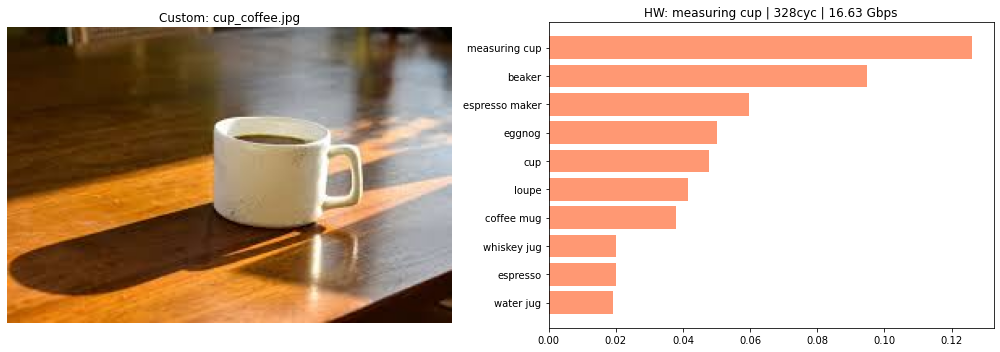

(647,
 array([3.05175781e-05, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 6.10351562e-05, 0.00000000e+00, 0.00000000e+00,
        3.05175781e-05, 0.00000000e+00, 3.05175781e-05, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        2.13623047e-04, 6.10351562e-05, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 3.05175781e-05, 3.05175781e-05,
        6.10351562e-05, 3.05175781e-05, 0.00000000e+00, 3.05175781e-05,
        1.22070312e-04, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 9.15527344e-05,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.05175781e-05,
        0.00000000e+00, 3.05175781e-05, 3.05175781e-05, 6.10351562e-05,
        3.05175781e-05, 6.10351562e-05, 6.10351562e-05, 0.

In [8]:
test_image("./cup_coffee.jpg")


════════════════════════════════════════════════════════════════
  Custom: daisy_flower.jpg
════════════════════════════════════════════════════════════════
  Scale: 0.4607 | max|logit|=15.19
  Compute: 328 cyc (0.9850 us) | 16.63 Gbps
  P1: 91682 | P2: 81622 | Stall: 32
  MAE: 0.001196 | KL: 0.915150 | Cos: 0.996225
  SWHW match: YES
────────────────────────────────────────────────────────────────
  Rank  SW (CPU float32)                 HW (FPGA Q1.15)
  ───── ──────────────────────────────── ──────────────────────────
  1    daisy                      0.9966  daisy                  0.391632
  2     earthstar                  0.0004   earthstar              0.010315
  3     ant                        0.0003   ant                    0.009094
  4     pinwheel                   0.0002   pinwheel               0.007294
  5     lacewing                   0.0001   lacewing               0.006805
════════════════════════════════════════════════════════════════


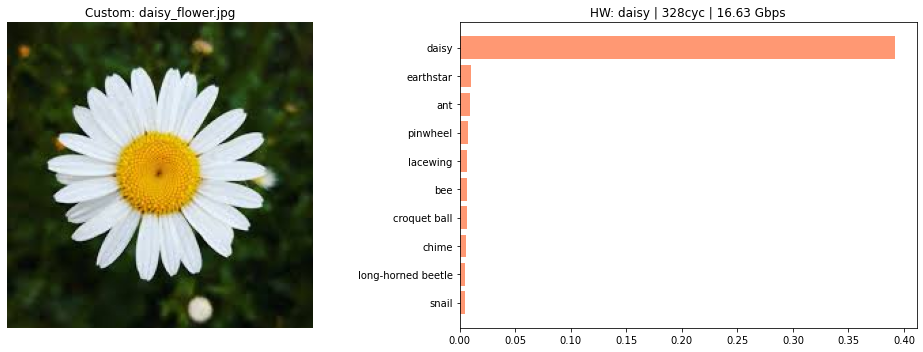

(985,
 array([2.13623047e-04, 4.57763672e-04, 0.00000000e+00, 0.00000000e+00,
        9.15527344e-05, 7.62939453e-04, 3.05175781e-05, 4.27246094e-04,
        1.22070312e-04, 1.52587891e-04, 7.62939453e-04, 7.93457031e-04,
        2.44140625e-04, 9.15527344e-05, 7.93457031e-04, 2.74658203e-04,
        5.49316406e-04, 4.88281250e-04, 3.35693359e-04, 3.05175781e-04,
        5.79833984e-04, 5.18798828e-04, 1.52587891e-04, 6.10351562e-05,
        2.44140625e-04, 8.54492188e-04, 1.77001953e-03, 2.04467773e-03,
        1.37329102e-03, 4.57763672e-04, 1.83105469e-04, 1.06811523e-03,
        9.15527344e-04, 6.10351562e-05, 1.22070312e-04, 2.74658203e-04,
        3.66210938e-04, 1.83105469e-04, 1.61743164e-03, 4.57763672e-04,
        8.54492188e-04, 6.71386719e-04, 1.31225586e-03, 3.32641602e-03,
        1.15966797e-03, 9.15527344e-05, 1.06811523e-03, 4.08935547e-03,
        6.10351562e-05, 1.83105469e-04, 1.22070312e-04, 4.88281250e-04,
        2.38037109e-03, 1.34277344e-03, 6.71386719e-04, 3.

In [9]:
test_image("./daisy_flower.jpg")


════════════════════════════════════════════════════════════════
  Custom: dog_1.jpg
════════════════════════════════════════════════════════════════
  Scale: 0.5503 | max|logit|=12.72
  Compute: 312 cyc (0.9369 us) | 17.49 Gbps
  P1: 92214 | P2: 82851 | Stall: 16
  MAE: 0.001121 | KL: 0.814008 | Cos: 0.951956
  SWHW match: YES
────────────────────────────────────────────────────────────────
  Rank  SW (CPU float32)                 HW (FPGA Q1.15)
  ───── ──────────────────────────────── ──────────────────────────
  1    golden retriever           0.8052  golden retriever       0.238831
  2     Labrador retriever         0.0264   Labrador retriever     0.036469
  3     Great Pyrenees             0.0245   Great Pyrenees         0.034912
  4     kuvasz                     0.0233   kuvasz                 0.033997
  5     Sussex spaniel             0.0204   Sussex spaniel         0.031677
════════════════════════════════════════════════════════════════


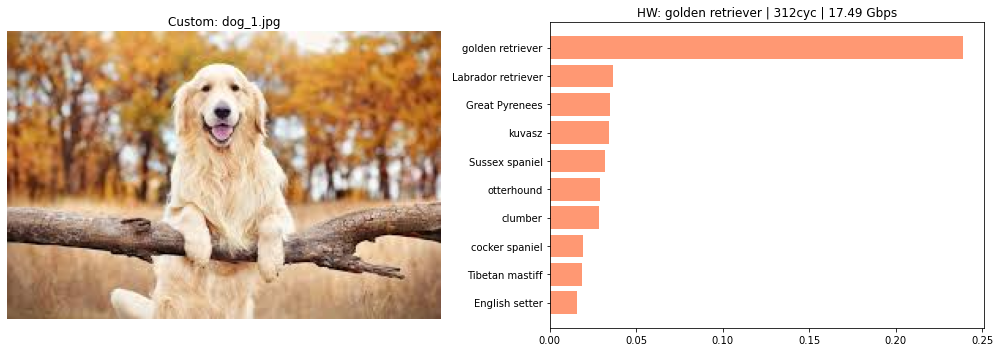

(207,
 array([1.22070312e-04, 1.22070312e-04, 0.00000000e+00, 3.05175781e-05,
        3.05175781e-05, 1.22070312e-04, 0.00000000e+00, 3.05175781e-05,
        1.22070312e-04, 0.00000000e+00, 2.44140625e-04, 1.22070312e-04,
        6.10351562e-05, 6.10351562e-05, 9.15527344e-05, 3.05175781e-05,
        3.05175781e-05, 9.15527344e-05, 3.05175781e-05, 1.22070312e-04,
        1.52587891e-04, 1.83105469e-04, 6.10351562e-05, 1.22070312e-04,
        2.44140625e-04, 6.10351562e-04, 5.18798828e-04, 3.05175781e-04,
        4.27246094e-04, 4.88281250e-04, 6.10351562e-05, 2.13623047e-04,
        5.79833984e-04, 1.22070312e-04, 3.96728516e-04, 1.22070312e-04,
        4.27246094e-04, 9.15527344e-05, 7.93457031e-04, 3.35693359e-04,
        3.96728516e-04, 5.18798828e-04, 3.66210938e-04, 5.18798828e-04,
        4.27246094e-04, 6.71386719e-04, 1.52587891e-04, 3.96728516e-04,
        3.05175781e-04, 2.13623047e-04, 1.83105469e-04, 3.05175781e-05,
        2.44140625e-04, 6.10351562e-05, 6.10351562e-05, 0.

In [10]:
test_image("./dog_1.jpg")

In [11]:
# =========================================================================
# Cell 9: Cleanup
# =========================================================================
in_buf.freebuffer(); out_buf.freebuffer()
print('Buffers freed. Done.')

Buffers freed. Done.
